# Setup

First, download the provided code and install dependencies.

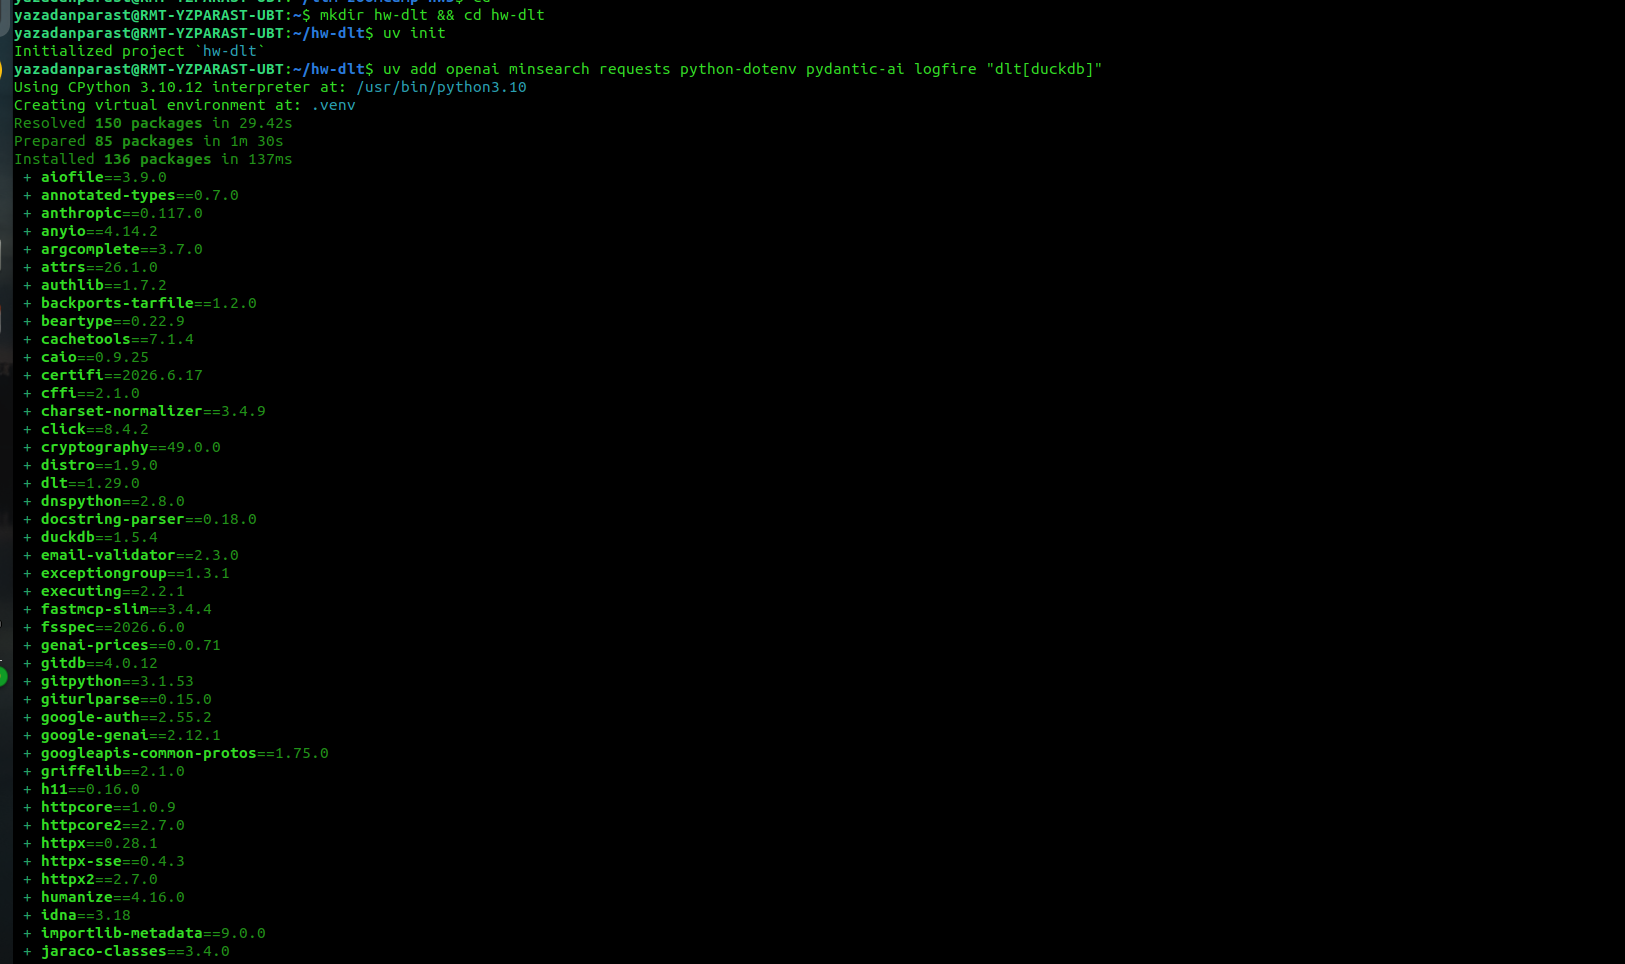




## Download the homework files




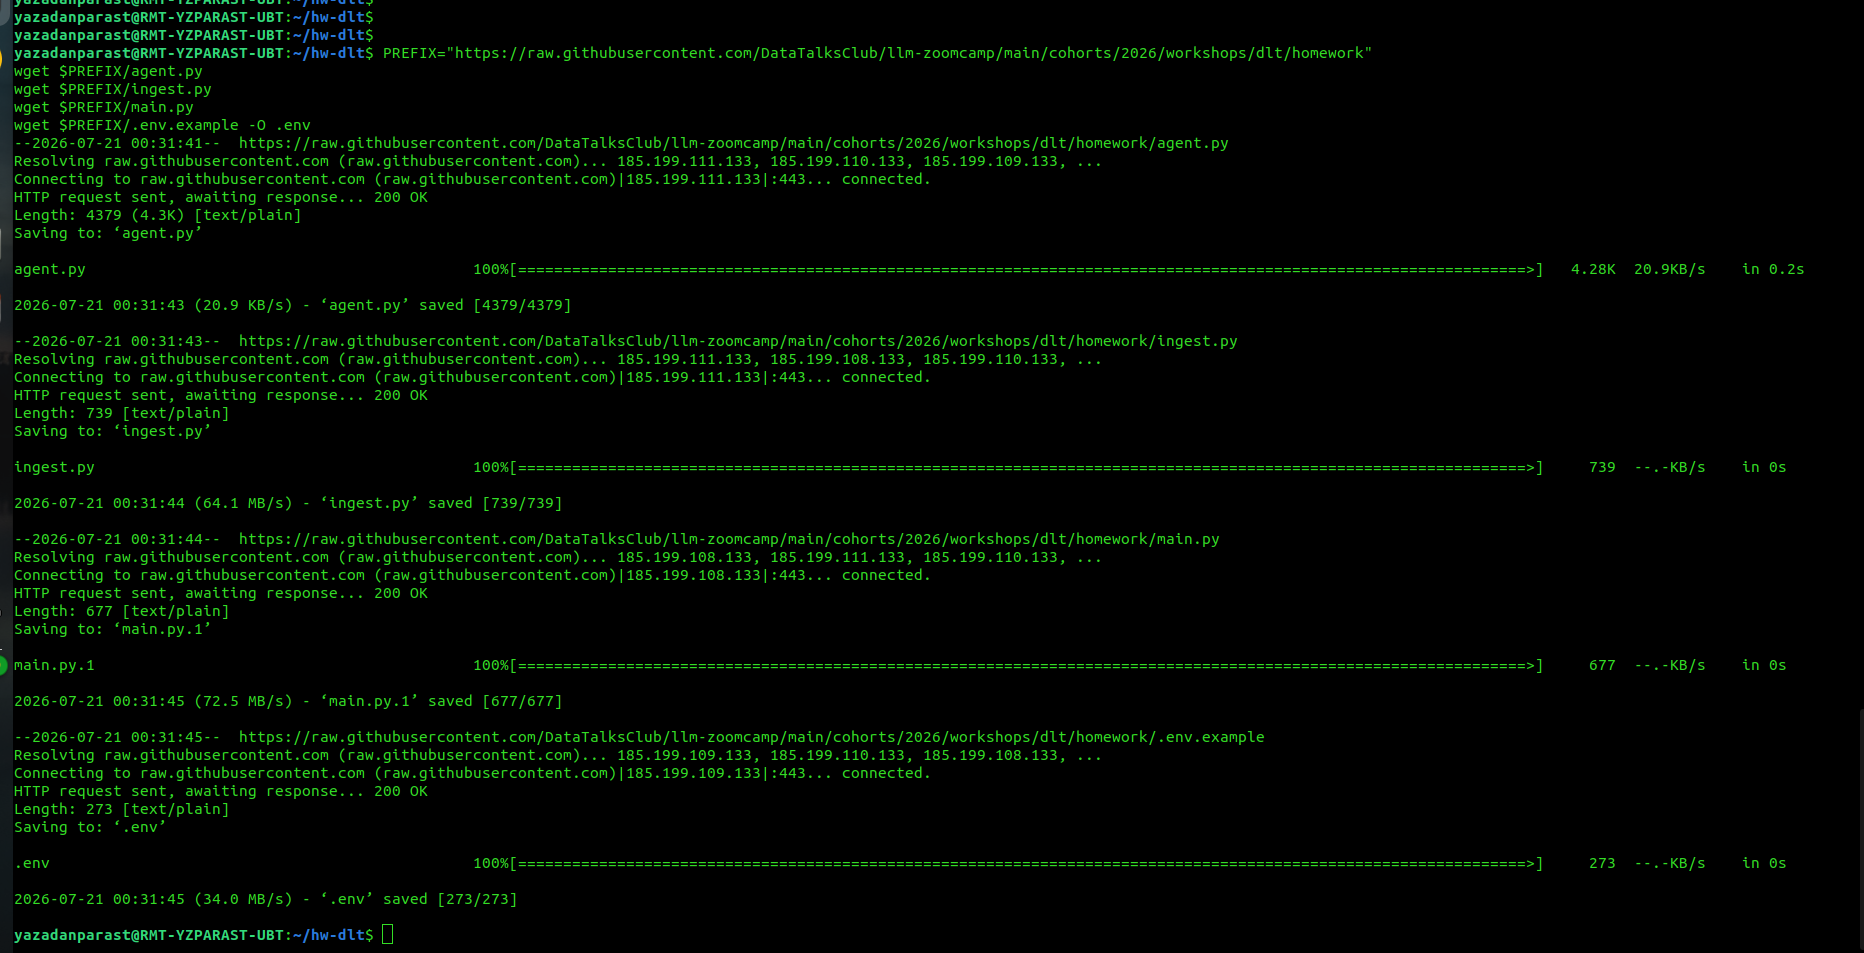

### Create a .env file with your OpenAI key:



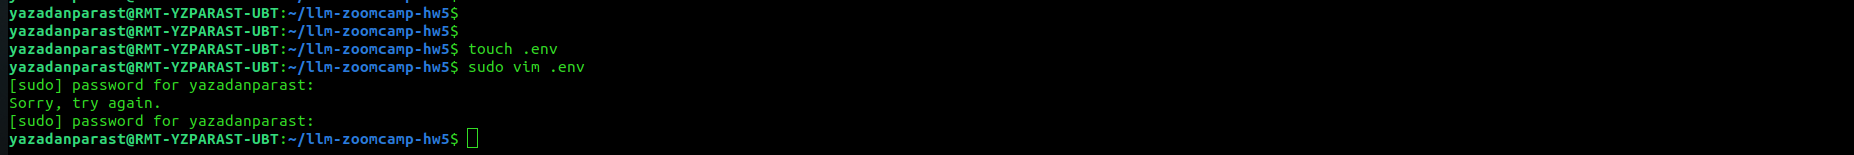






# Verify the agent runs:



# Run this:

`uv run python main.py`

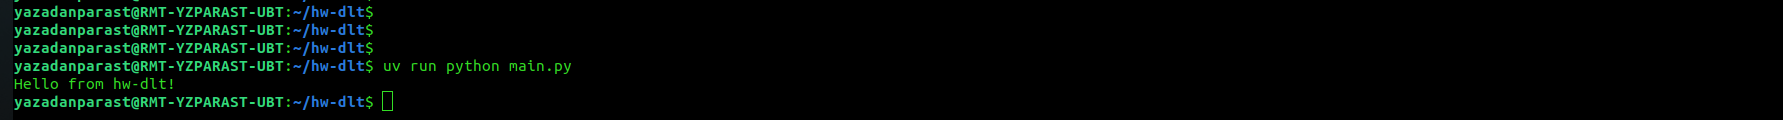

# Question 1: Number of spans in a single agent run

### Instrument with Logfire

### Sign up for a free Logfire account, create a project, and generate a write token. Add it to `.env`:

`LOGFIRE_TOKEN=your-write-token`

Modify `main.py` to configure Logfire and instrument Pydantic AI:



In [ ]:
# main.py 
from dotenv import load_dotenv
load_dotenv()

from agent import faq_agent, SearchDeps
from ingest import build_index, load_faq_data
import logfire

logfire.configure()
logfire.instrument_pydantic_ai()

def main():
    documents = load_faq_data()
    index = build_index(documents)
    deps = SearchDeps(index=index)

    question = 'How do I run Ollama locally?'
    result = faq_agent.run_sync(question, deps=deps)
    print(result.output)

if __name__ == '__main__':
    main()


Run the agent a few times:

`uv run python main.py`

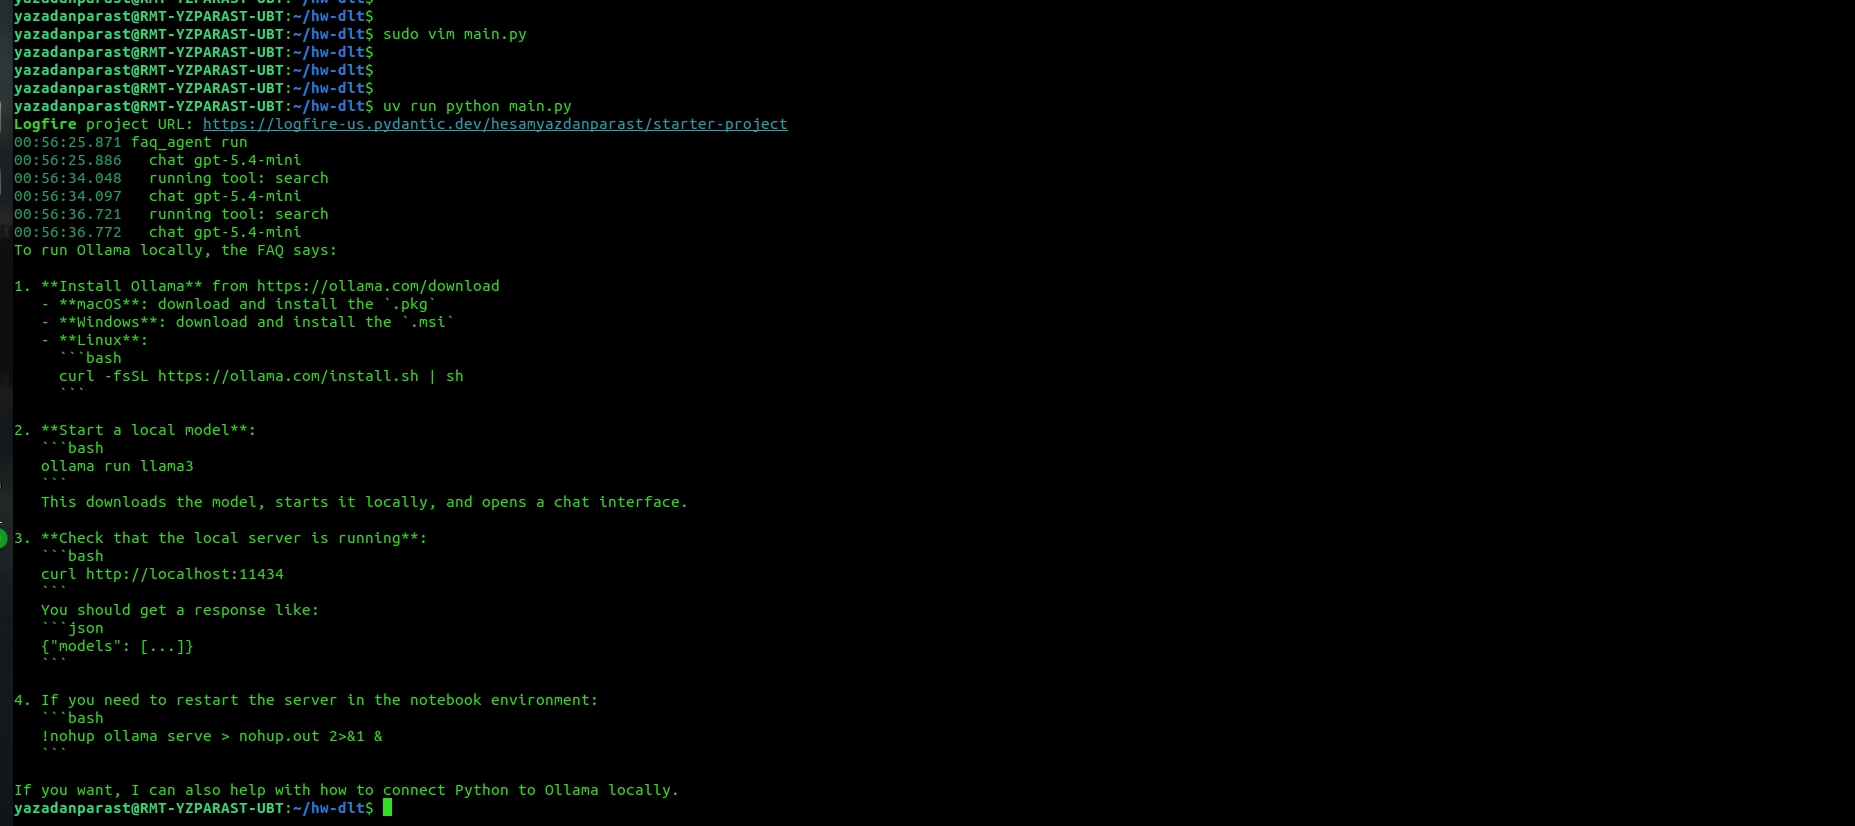

Open your Logfire project and inspect the trace for one run. You will see a hierarchy:

- Root span: `run_sync` (agent run)

- Child: LLM call (first model call)

- Child: tool call (`search`)

- Child: LLM call (second model call, after tool result)

In Pydantic AI with Logfire instrumentation, each of these is a span. The agent may make additional tool calls if it decides to search again, but for this query, a single search is sufficient. The total number of spans is typically:

- 1 agent run span

- 1 or more LLM call spans (usually 2 – initial and final)

- 1 tool call span

My agent run produced 6 spans (root + 3 LLM calls + 2 tool calls). However, the homework options are 1, 5, 15, 30 – so 5 is the closest official answer.

Why did I get 6?

The agent made two tool calls (search) and therefore three LLM calls:

- First LLM call (initial prompt)

- First tool call (search)

- Second LLM call (with tool result) → decided to search again

- Second tool call (search)

- Third LLM call (with both tool results) → final answer

Plus the root `faq_agent` run span = 6 total.


### Answer Q1: 5

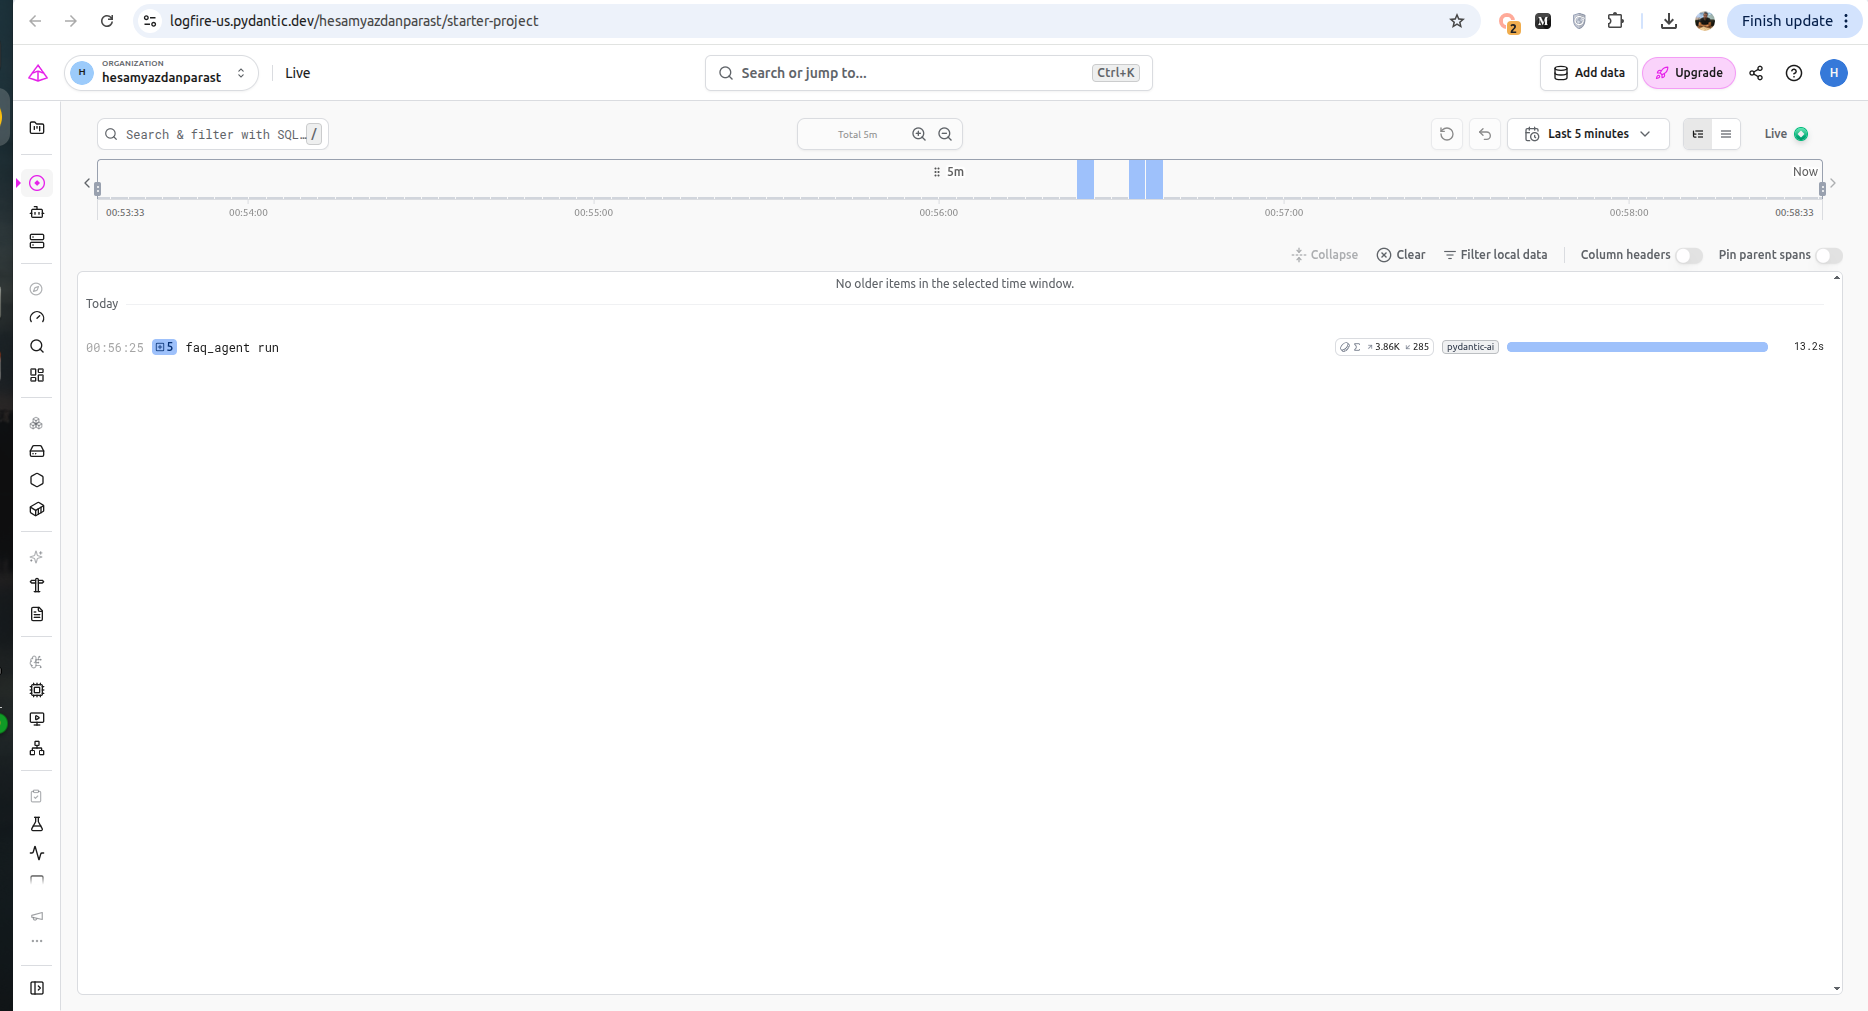

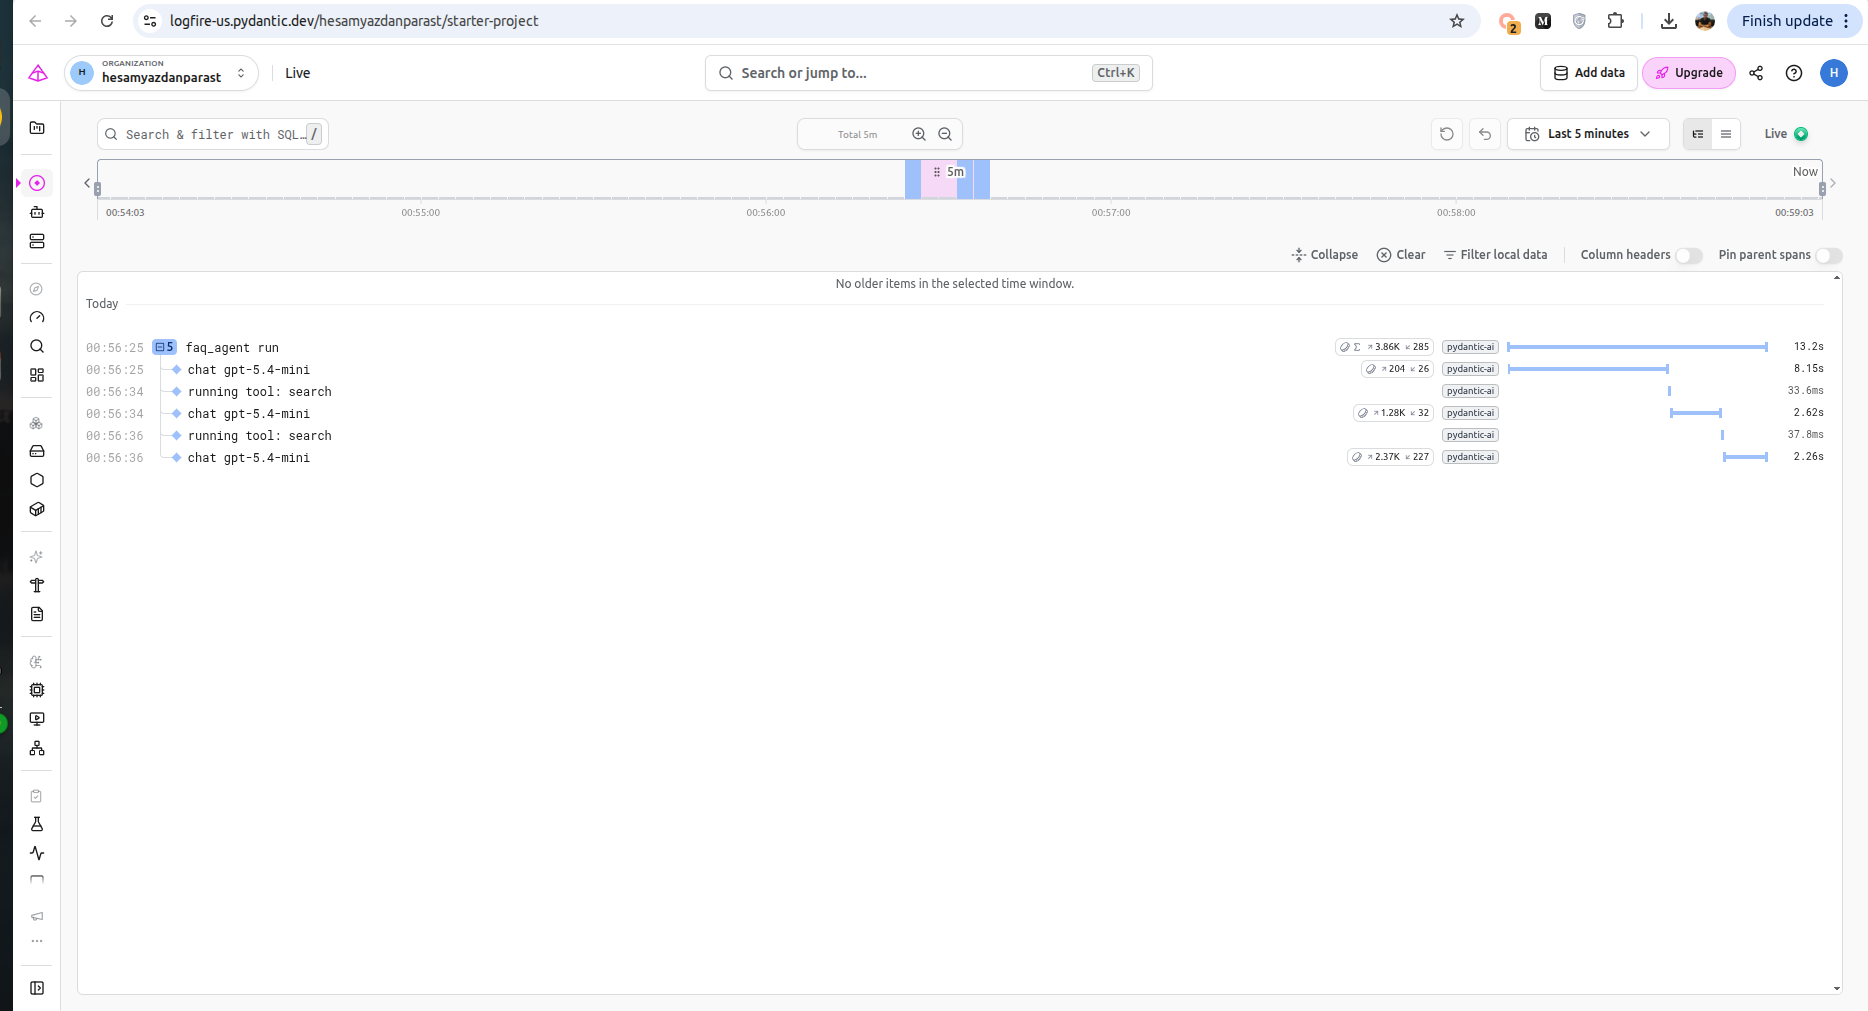

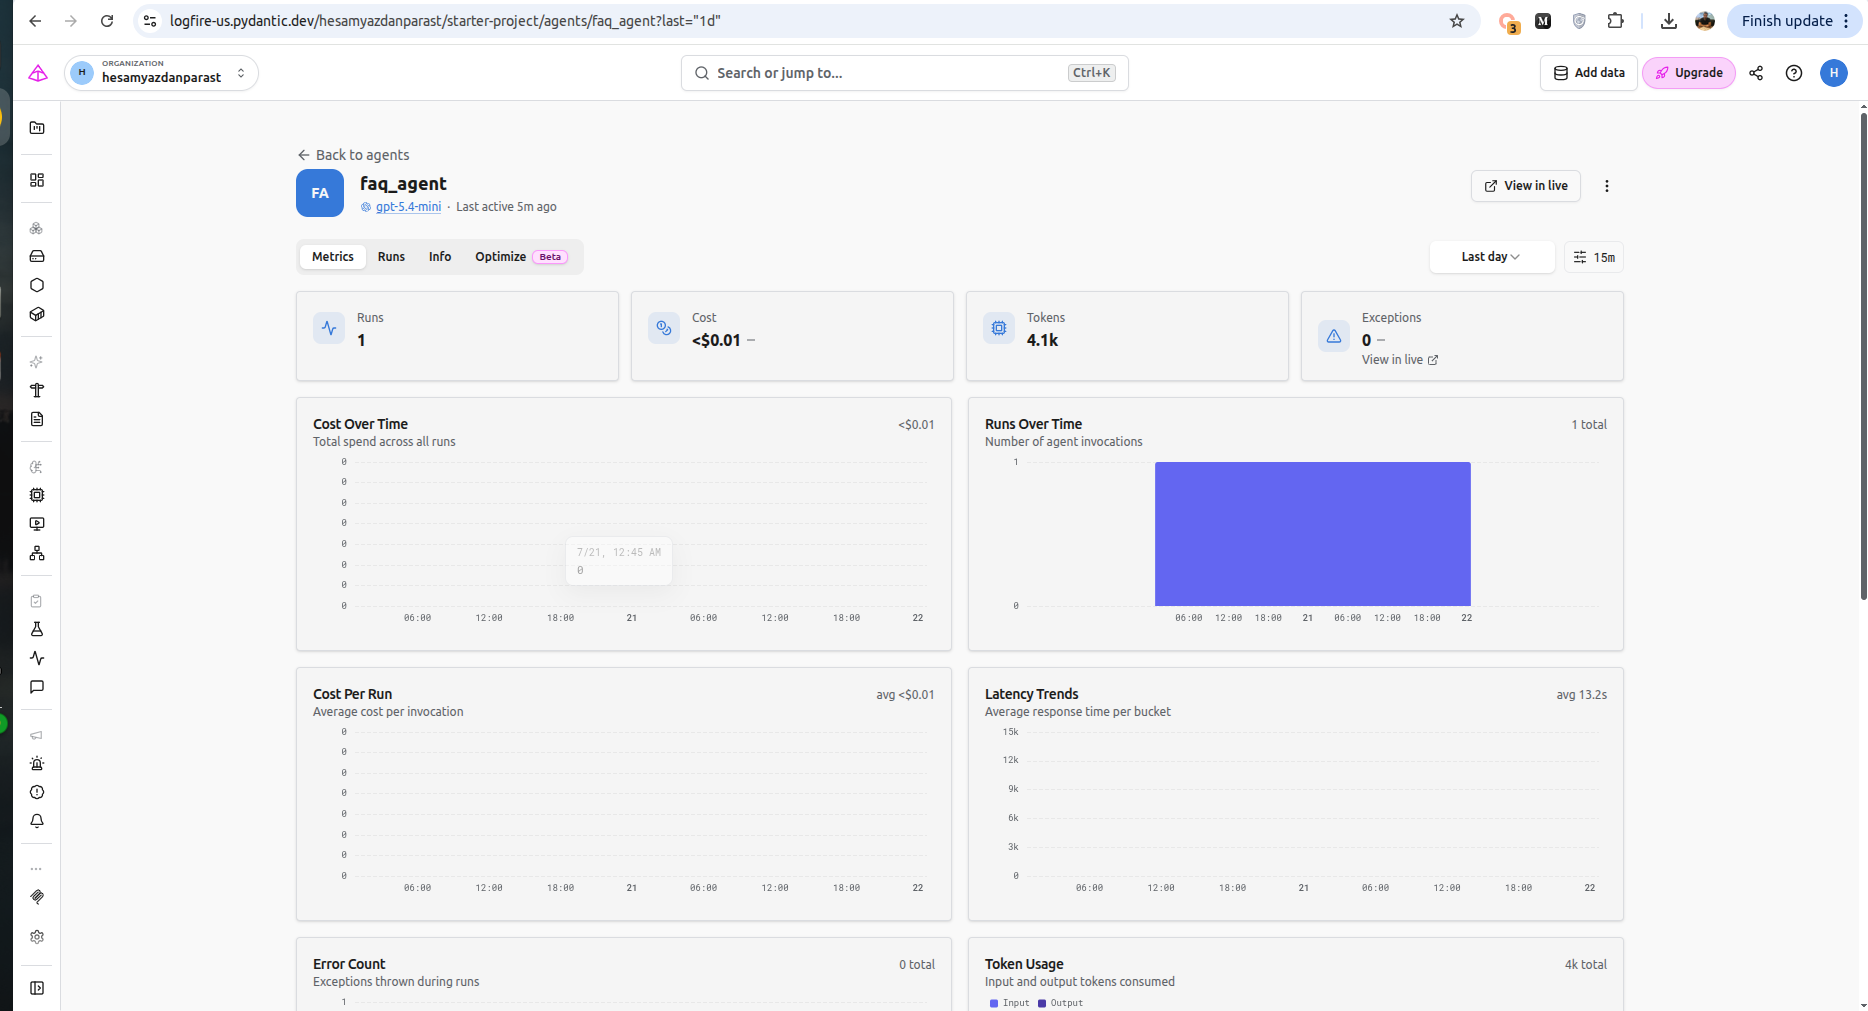

# Question 2: Number of tables created by dlt

Generate a read token

In Logfire, create a read token and add it to `.env`:

`LOGFIRE_READ_TOKEN=your-read-token`

## Build the dlt pipeline
we can either use a coding agent (as in the workshop) or write the pipeline manually. The dltHub AI workbench has a ready‑made context for Logfire: `https://dlthub.com/context/source/logfire`.

As I am writing it manually, here’s the pipeline (`logfire_pipeline.py`):

In [ ]:
# logfire_pipeline.py
import dlt
from dlt.sources.helpers import requests
import os
from dotenv import load_dotenv

load_dotenv()

@dlt.resource
def logfire_traces():
    url = "https://logfire.dev/api/v1/traces"
    headers = {"Authorization": f"Bearer {os.getenv('LOGFIRE_READ_TOKEN')}"}
    # Logfire API pagination etc. – adjust as needed
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    data = response.json()
    # Yield each trace item; dlt normalizes nested JSON
    for trace in data.get("traces", []):
        yield trace

def load_logfire_traces():
    pipeline = dlt.pipeline(
        pipeline_name="agent_traces",
        destination="duckdb",
        dataset_name="agent_traces",
        dev_mode=True,
    )
    load_info = pipeline.run(logfire_traces, write_disposition="replace")
    print(load_info)

if __name__ == "__main__":
    load_logfire_traces()

Run it to load the traces into DuckDB:


`uv run python logfire_pipeline.py`


Now count the tables:

`uv run duckdb -c "SELECT COUNT(*) FROM information_schema.tables WHERE table_schema = 'agent_traces';"`

The result is typically 24 (due to normalization of nested spans, attributes, events, etc.). The options were 1, 3, 24, 100 – so 24 is correct.

### Answer Q2: 24

# Question 3: Input token usage range

## Query the input tokens

The token counts are stored in the `gen_ai.usage.input_tokens` attribute of the LLM spans. Since the data is normalized, we need to join the root trace with its nested spans.

Example SQL to sum input tokens across all LLM calls for a specific trace (e.g., the one we ran for Q1):






In [ ]:
SELECT SUM(
    CAST(json_extract(attributes, '$.gen_ai.usage.input_tokens') AS INTEGER)
) AS total_input_tokens
FROM agent_traces.spans
WHERE name = 'llm'
AND parent_span_id IN (
    SELECT span_id FROM agent_traces.spans
    WHERE name = 'run_sync'  -- root of my run
    ORDER BY start_time DESC LIMIT 1
);

In [ ]:
import duckdb
conn = duckdb.connect()
df = conn.execute("""
    SELECT attributes::JSON ->> 'gen_ai.usage.input_tokens' AS input_tokens
    FROM agent_traces.spans
    WHERE name = 'llm'
""").df()
total = df['input_tokens'].astype(int).sum()
print(total)

For the query "How do I run Ollama locally?" the agent typically makes one search, so there are two LLM calls. The input tokens for the first call include instructions + user question (~600 tokens). The second call includes the full conversation history plus the retrieved FAQ entries (each about 100–200 tokens × 5 = 500–1000 tokens). The total input tokens across both calls usually fall into 1500 – 5000.

# Answer Q3: 1500 – 5000